In [1]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs                 # For plotting maps
import cartopy.feature as cfeature         # For plotting maps
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
import warnings

In [2]:
#Read in SO4, NO3, NH4 wet dep timeseries files
daily_result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Timeseries_atm_h2')
daily_files_to_open = ['FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.WD_HNO3.nc', 
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.WD_NH4.nc', 
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_a1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_a2SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_a3SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_c1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_c2SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_c3SFWET.nc', 
                          'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.PRECC.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.PRECL.nc']
                           
# Concatenate directory path with each file name separately
file_paths = [daily_result_dir / file_name for file_name in daily_files_to_open]

# Open multiple netCDF files as a single dataset
nc_daily = xr.open_mfdataset(file_paths, combine='nested')

/glade/u/home/demurray/.local/lib/python3.10/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'cfgrib' loading failed:
ecCodes library not found using ['eccodes', 'libeccodes.so', 'libeccodes']
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


In [3]:
# Calculate SO4_wet_sum
nc_daily['SO4_wet_sum'] = (nc_daily['so4_a1SFWET'] + nc_daily['so4_a2SFWET'] + nc_daily['so4_a3SFWET'] 
                                + nc_daily['so4_c1SFWET'] + nc_daily['so4_c2SFWET'] + nc_daily['so4_c3SFWET']) * -1

# Calculate NO3_wet
nc_daily['NO3_wet'] = nc_daily['WD_HNO3'] * -1 * 0.984006 #correct for HNO3 molar mass

# Calculate NH4_wet
nc_daily['WD_NH4_corr'] = nc_daily['WD_NH4'] * -1
nc_daily['WD_NH4_corr'] = nc_daily['WD_NH4_corr'].where(nc_daily['WD_NH4_corr'] != -0.0, 0.0)

# calculate total precip
nc_daily['PRECC_mm'] = nc_daily['PRECC']* (86400*1000) # seconds to days and m to mm = mm/d
nc_daily['PRECL_mm'] = nc_daily['PRECL']* (86400*1000)
nc_daily['PREC_tot_mm'] = nc_daily['PRECC_mm']  + nc_daily['PRECL_mm']

# Perform unit conversions
conversions = 86400 * 1000000  # seconds to days and kg to mg per m2
nc_daily = nc_daily.apply(lambda x: x * conversions if x.name in ['SO4_wet_sum', 'WD_NH4_corr', 'NO3_wet'] else x)
nc_daily_sub = nc_daily[['SO4_wet_sum', 'NO3_wet', 'WD_NH4_corr', 'PREC_tot_mm']]
nc_daily_sub

<xarray.Dataset>
Dimensions:      (time: 7671, lat: 192, lon: 288)
Coordinates:
  * lat          (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon          (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time         (time) datetime64[ns] 2002-01-01 2002-01-02 ... 2023-01-01
Data variables:
    SO4_wet_sum  (time, lat, lon) float64 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    NO3_wet      (time, lat, lon) float64 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    WD_NH4_corr  (time, lat, lon) float64 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    PREC_tot_mm  (time, lat, lon) float64 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>

In [4]:
#Calculate the total annual average for each solute
# assign year
nc_daily_sub['year'] = nc_daily_sub['time'].dt.year

#Subset data for MUSICA overlap (delete if needed)
exclude_date = np.datetime64('2018-12-31')

# Subset the dataset for the years 2017 and 2018, and drop 2018-12-31
nc_daily_sub= nc_daily_sub.where(
    ((nc_daily_sub['year'] == 2017) | (nc_daily_sub['year'] == 2018)) & 
    (nc_daily_sub['time'] != exclude_date), 
    drop=True
)
daily_mean_inorg = nc_daily_sub.mean(dim = 'time')
daily_mean_inorg

<xarray.Dataset>
Dimensions:      (lat: 192, lon: 288)
Coordinates:
  * lat          (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon          (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Data variables:
    SO4_wet_sum  (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    NO3_wet      (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    WD_NH4_corr  (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    PREC_tot_mm  (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    year         float64 2.017e+03

In [5]:
#Do the same thing for the organic files
#Read in BC wet dep timeseries files
result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Timeseries_atm_h2')
bc_files_to_open = ['FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.a2x_BCPHIWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_a1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_a4SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_c1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_c4SFWET.nc']

file_paths = [result_dir / file_name for file_name in bc_files_to_open]
nc_daily_bc = xr.open_mfdataset(file_paths, combine='nested')

#read in POM files
daily_pom_to_open = 'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.pom_*SFWET.nc'
nc_daily_pom = xr.open_mfdataset(str(result_dir/daily_pom_to_open),combine='nested')

#read in SOA
soa_result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Timeseries_atm_SOAvars/')
daily_soa_to_open = 'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.*SFWET.nc'
nc_daily_soa = xr.open_mfdataset(str(soa_result_dir/daily_soa_to_open),combine='nested')

#merge SOA and POM files together
nc_daily_oc = xr.merge([nc_daily_soa, nc_daily_pom, nc_daily_bc])

# Calculate DOC = SOA + POM + BC
nc_daily_oc['BC_wet_sum'] = (nc_daily_oc['bc_a1SFWET'] + nc_daily_oc['bc_a4SFWET'] + nc_daily_oc['bc_c1SFWET'] 
                                + nc_daily_oc['bc_c4SFWET']) * -1

nc_daily_oc['SOA_POM_wet_sum'] = (nc_daily_oc['soa1_a1SFWET'] + nc_daily_oc['soa1_a2SFWET'] + nc_daily_oc['soa1_c1SFWET'] 
                             + nc_daily_oc['soa1_c2SFWET'] + nc_daily_oc['soa2_a1SFWET'] + nc_daily_oc['soa2_a2SFWET'] 
                             + nc_daily_oc['soa2_c1SFWET'] +  nc_daily_oc['soa2_c2SFWET'] + nc_daily_oc['soa3_a1SFWET'] 
                             + nc_daily_oc['soa3_a2SFWET'] + nc_daily_oc['soa3_c1SFWET'] + nc_daily_oc['soa3_c2SFWET'] 
                             + nc_daily_oc['soa4_a1SFWET'] + nc_daily_oc['soa4_a2SFWET'] + nc_daily_oc['soa4_c1SFWET'] 
                             + nc_daily_oc['soa4_c2SFWET'] + nc_daily_oc['soa5_a1SFWET'] + nc_daily_oc['soa5_a2SFWET'] 
                             + nc_daily_oc['soa5_c1SFWET'] + nc_daily_oc['soa5_c2SFWET'] + nc_daily_oc['pom_a1SFWET']
                             + nc_daily_oc['pom_a4SFWET'] + nc_daily_oc['pom_c1SFWET'] + nc_daily_oc['pom_c4SFWET']) * -1

nc_daily_oc['SOA_POM_BC_wet_sum'] = nc_daily_oc['BC_wet_sum'] + nc_daily_oc['SOA_POM_wet_sum']

# Perform unit conversions
conversions = 86400 * 1000000  # seconds to days and kg to mg per m2
nc_daily_oc = nc_daily_oc.apply(lambda x: x * conversions if x.name in ['BC_wet_sum', 'SOA_POM_wet_sum', 'SOA_POM_BC_wet_sum'] else x)
nc_daily_oc = nc_daily_oc[[ 'BC_wet_sum', 'SOA_POM_wet_sum', 'SOA_POM_BC_wet_sum']]
nc_daily_oc

<xarray.Dataset>
Dimensions:             (time: 7671, lat: 192, lon: 288)
Coordinates:
  * lat                 (lat) float64 -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon                 (lon) float64 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * time                (time) datetime64[ns] 2002-01-01 ... 2023-01-01
Data variables:
    BC_wet_sum          (time, lat, lon) float64 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    SOA_POM_wet_sum     (time, lat, lon) float64 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    SOA_POM_BC_wet_sum  (time, lat, lon) float64 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>

In [6]:
#Calculate the total annual average for each solute
# assign year
nc_daily_oc['year'] = nc_daily_oc['time'].dt.year

#Subset data for MUSICA overlap (delete if needed)
exclude_date = np.datetime64('2018-12-31')

# Subset the dataset for the years 2017 and 2018, and drop 2018-12-31
nc_daily_oc= nc_daily_oc.where(
    ((nc_daily_oc['year'] == 2017) | (nc_daily_oc['year'] == 2018)) & 
    (nc_daily_oc['time'] != exclude_date), 
    drop=True
)
daily_mean_org = nc_daily_oc.mean(dim = 'time')
daily_mean_org

<xarray.Dataset>
Dimensions:             (lat: 192, lon: 288)
Coordinates:
  * lat                 (lat) float64 -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon                 (lon) float64 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
Data variables:
    BC_wet_sum          (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    SOA_POM_wet_sum     (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    SOA_POM_BC_wet_sum  (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    year                float64 2.017e+03

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


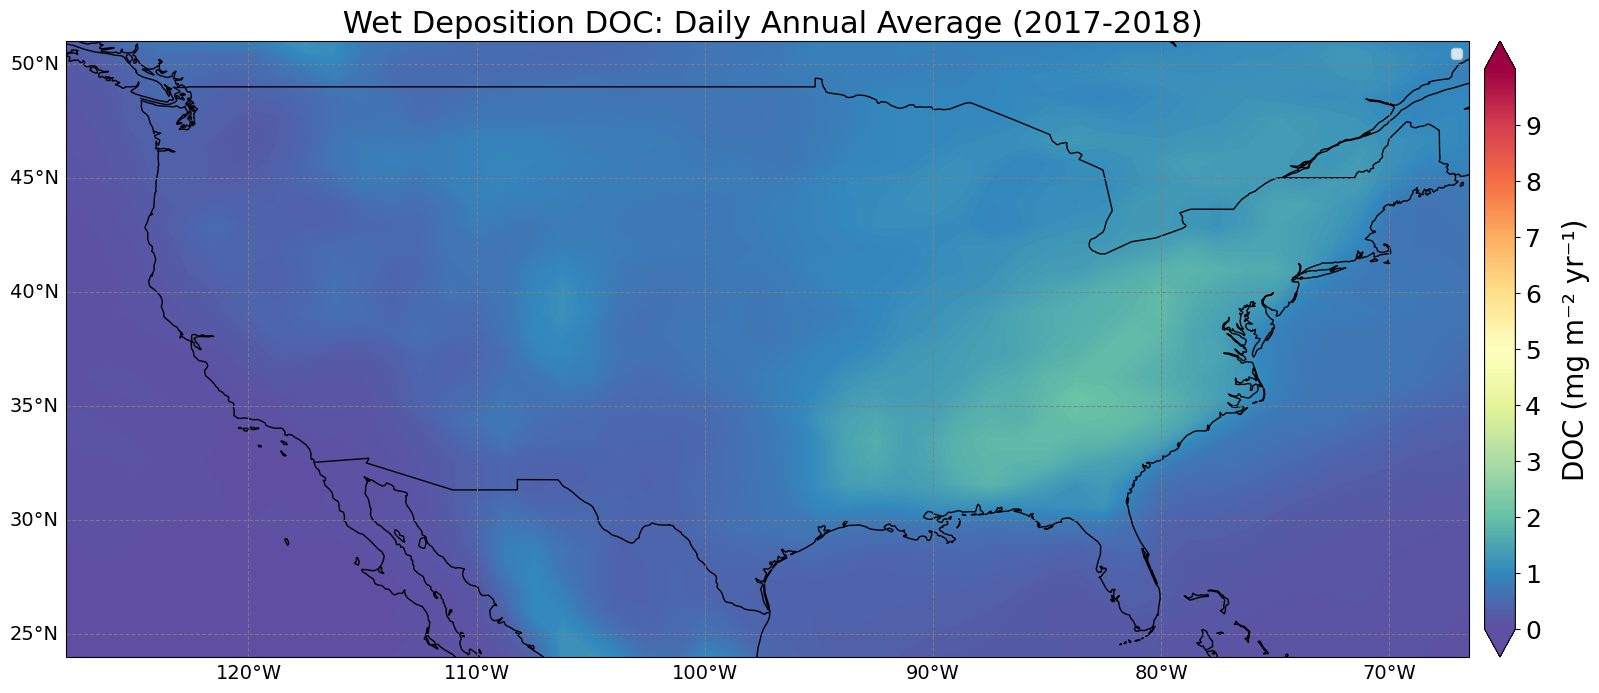

In [21]:
#make a map
warnings.filterwarnings("ignore") # Suppress specific warning types

#setup:
#var_sel = daily_mean_inorg[['PREC_tot_mm']].to_dataarray()
#var_sel = daily_mean_inorg[['NO3_wet']].to_dataarray()
#var_sel = daily_mean_inorg[['WD_NH4_corr']].to_dataarray()
#var_sel = daily_mean_inorg[['SO4_wet_sum']].to_dataarray()
var_sel = daily_mean_org[['SOA_POM_BC_wet_sum']].to_dataarray()
var_srf = var_sel.isel(variable=0) 

#extract grid variables
lat = var_sel.coords['lat']
lon = var_sel.coords['lon']

plt.figure(figsize=(20,8))

#Define projection
ax = plt.axes(projection=ccrs.PlateCarree())

# Zoom to a region
#longitude limits in degrees, latitude limits in degrees
ax.set_xlim(-128,-66.5)
ax.set_ylim(24,51)

#define contour levels
clev = np.arange(0, 10, 0.0001)

#plot the data
cmap = plt.cm.get_cmap('Spectral_r')
contour = plt.contourf(lon,lat,var_srf,clev, cmap=cmap,extend='both')

# add coastlines
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

#add lat lon grids
gl = ax.gridlines(draw_labels=True, color='grey', alpha=0.8, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabel_style = {'size': 14}
gl.ylabel_style = {'size': 14}

# Titles
#plt.title("Global model, Precipitation depth (mm):  Daily Annual Average (2017-2018)",fontsize=22)
#plt.title(" Wet Deposition $NH_{4}$: Daily Annual Average (2017-2018)",fontsize=22)
plt.title(" Wet Deposition DOC: Daily Annual Average (2017-2018)",fontsize=22)

# y-axis
ax.text(-0.04, 0.5, '', va='bottom', ha='center',
        rotation='vertical', rotation_mode='anchor',
        transform=ax.transAxes, fontsize=16)

# x-axis
ax.text(0.5, -0.08, '', va='bottom', ha='center',
        rotation='horizontal', rotation_mode='anchor',
        transform=ax.transAxes, fontsize=16)

# Add color bar
cbar = plt.colorbar(contour, pad=0.01, fraction=0.03)  # Adjust pad and fraction values as needed
#cbar.set_label('Precipitation (mm d⁻¹)', labelpad=15, fontsize=20)  # Adjust labelpad value as needed
#cbar.set_label('$NH_{4}$ (mg m⁻² d⁻¹)', labelpad=15, fontsize=20)  # Adjust labelpad value as needed
cbar.set_label('DOC (mg m⁻² yr⁻¹)', labelpad=15, fontsize=20)  # Adjust labelpad value as needed
cbar.ax.tick_params(labelsize=18)  # Adjust color bar tick size
plt.legend()
plt.show()